In [168]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

# Generate synthetic data
np.random.seed(42)
m = 1000
X = np.random.randn(m, 2)
theta_star = np.array([3.0, 4.0]).reshape(2, 1)
epsilon = np.random.randn(m, 1) 
y = X @ theta_star + epsilon

theta_0 = np.array([1.0, 1.0]).reshape(2, 1)
alpha_const = 0.5

# Calculate loss and gradient
def compute_loss(theta, X, y):
    m = len(y)
    diff = X @ theta - y
    return (1.0 / (2 * m)) * np.sum(diff ** 2)

def compute_gradient(theta, X_batch, y_batch):
    m_batch = len(y_batch)
    return (1.0 / m_batch) * X_batch.T @ (X_batch @ theta - y_batch)

# Grid data for contour plot
theta1_vals = np.linspace(-0.5, 4.5, 100)
theta2_vals = np.linspace(0.0, 5.0, 100)
T1, T2 = np.meshgrid(theta1_vals, theta2_vals)
Loss_grid = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        t = np.array([[T1[i, j]], [T2[i, j]]])
        Loss_grid[i, j] = compute_loss(t, X, y)

def full_batch_gd(X, y, theta_init, alpha, iterations):
    """Full Batch Gradient Descent"""
    theta = theta_init.copy()
    history = [theta.copy()]
    losses = [compute_loss(theta, X, y)]
    
    for _ in range(iterations):
        grad = compute_gradient(theta, X, y)
        theta = theta - alpha * grad
        history.append(theta.copy())
        losses.append(compute_loss(theta, X, y))
        
    return np.array(history), np.array(losses)

def mini_batch_sgd(X, y, theta_init, alpha, batch_size, updates, method='constant', beta=0.9, eps=1e-8):
    """Mini-batch Stochastic Gradient Descent"""
    theta = theta_init.copy()
    history = [theta.copy()]
    losses = [compute_loss(theta, X, y)] # Record full-batch loss
    
    m = len(y)
    v = np.zeros_like(theta) # For NAG
    G = np.zeros_like(theta) # For Adagrad
    
    update_count = 0
    while update_count < updates:
        # Shuffle data before each epoch
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, m, batch_size):
            if update_count >= updates:
                break
                
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            if method == 'constant':
                grad = compute_gradient(theta, X_batch, y_batch)
                theta = theta - alpha * grad
                
            elif method == 'NAG':
                theta_ahead = theta - beta * v
                grad_ahead = compute_gradient(theta_ahead, X_batch, y_batch)
                v = beta * v + alpha * grad_ahead
                theta = theta - v
                
            elif method == 'Adagrad':
                grad = compute_gradient(theta, X_batch, y_batch)
                G += grad ** 2
                theta = theta - (alpha / np.sqrt(G + eps)) * grad
            
            history.append(theta.copy())
            losses.append(compute_loss(theta, X, y))
            update_count += 1
            
    return np.array(history), np.array(losses)

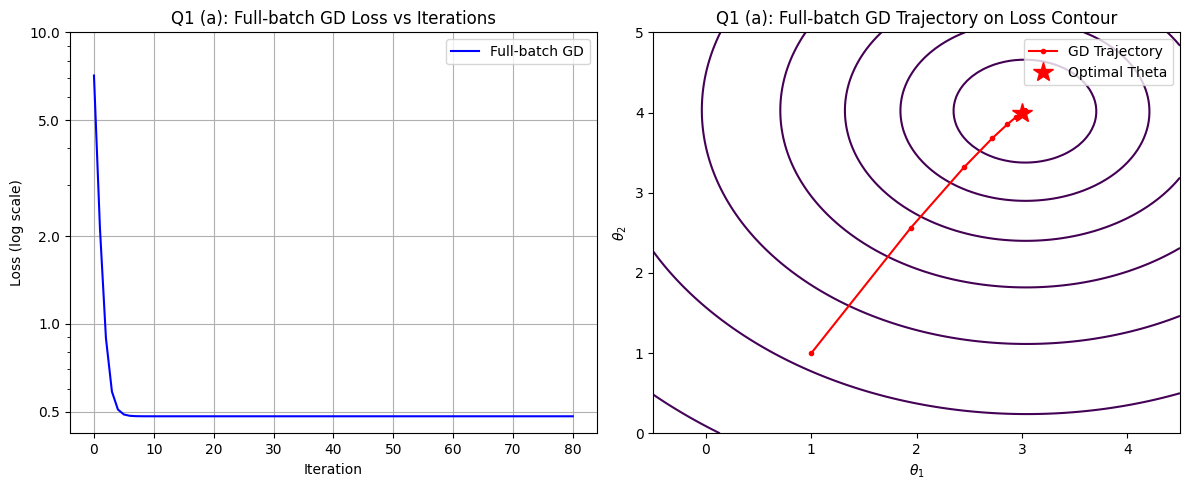

In [169]:
# Run full-batch GD for 80 iterations
hist_gd, loss_gd = full_batch_gd(X, y, theta_0, alpha=alpha_const, iterations=80)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
axes[0].plot(loss_gd, label='Full-batch GD', color='blue')
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter()) # Use standard numeric format
axes[0].set_yticks([0.5, 1, 2, 5, 10])
axes[0].set_title('Q1 (a): Full-batch GD Loss vs Iterations')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss (log scale)')
axes[0].grid(True)
axes[0].legend()

# Trajectory plot
axes[1].contour(T1, T2, Loss_grid, levels=np.logspace(-1, 3, 20), cmap='viridis')
axes[1].plot(hist_gd[:, 0], hist_gd[:, 1], 'r.-', label='GD Trajectory')
axes[1].plot(theta_star[0], theta_star[1], 'r*', markersize=15, label='Optimal Theta')
axes[1].set_title('Q1 (a): Full-batch GD Trajectory on Loss Contour')
axes[1].set_xlabel(r'$\theta_1$')
axes[1].set_ylabel(r'$\theta_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

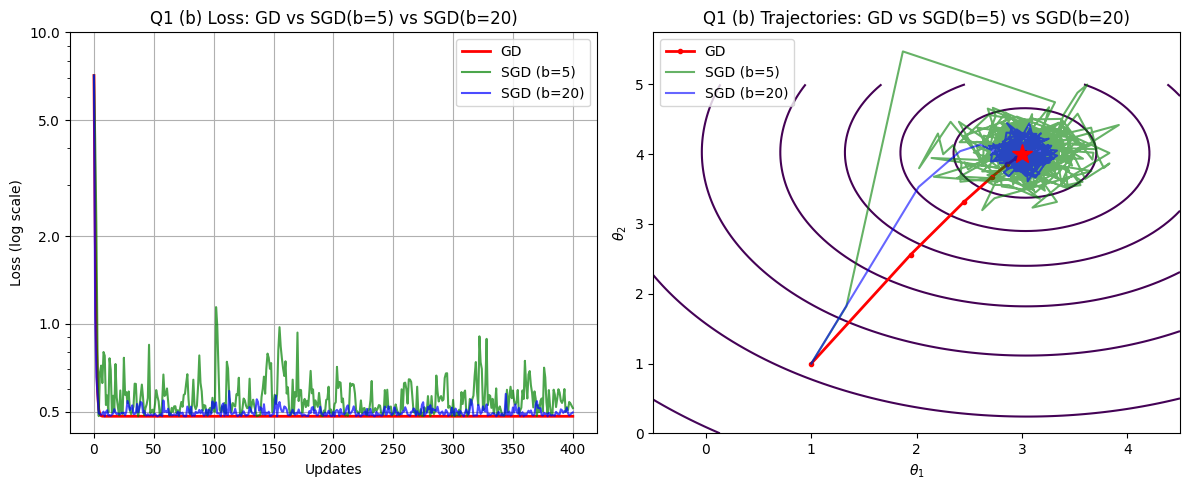

In [170]:
hist_gd, loss_gd = full_batch_gd(X, y, theta_0, alpha=alpha_const, iterations=400)
hist_sgd5, loss_sgd5 = mini_batch_sgd(X, y, theta_0, alpha=alpha_const, batch_size=5, updates=400)
hist_sgd20, loss_sgd20 = mini_batch_sgd(X, y, theta_0, alpha=alpha_const, batch_size=20, updates=400)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss comparison plot
axes[0].plot(loss_gd, label='GD', color='r', linewidth=2)
axes[0].plot(loss_sgd5, alpha=0.7, label='SGD (b=5)', color='g')
axes[0].plot(loss_sgd20, alpha=0.7, label='SGD (b=20)', color='b')
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter()) # Use standard numeric format
axes[0].set_yticks([0.5, 1, 2, 5, 10])
axes[0].set_title('Q1 (b) Loss: GD vs SGD(b=5) vs SGD(b=20)')
axes[0].set_xlabel('Updates')
axes[0].set_ylabel('Loss (log scale)')
axes[0].grid(True)
axes[0].legend()

# Trajectory comparison plot
axes[1].contour(T1, T2, Loss_grid, levels=np.logspace(-1, 3, 20), cmap='viridis')
axes[1].plot(hist_gd[:, 0], hist_gd[:, 1], 'r.-', label='GD', linewidth=2)
axes[1].plot(hist_sgd5[:, 0], hist_sgd5[:, 1], 'g-', alpha=0.6, label='SGD (b=5)')
axes[1].plot(hist_sgd20[:, 0], hist_sgd20[:, 1], 'b-', alpha=0.6, label='SGD (b=20)')
axes[1].plot(theta_star[0], theta_star[1], 'r*', markersize=15)
axes[1].set_title('Q1 (b) Trajectories: GD vs SGD(b=5) vs SGD(b=20)')
axes[1].set_xlabel(r'$\theta_1$')
axes[1].set_ylabel(r'$\theta_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

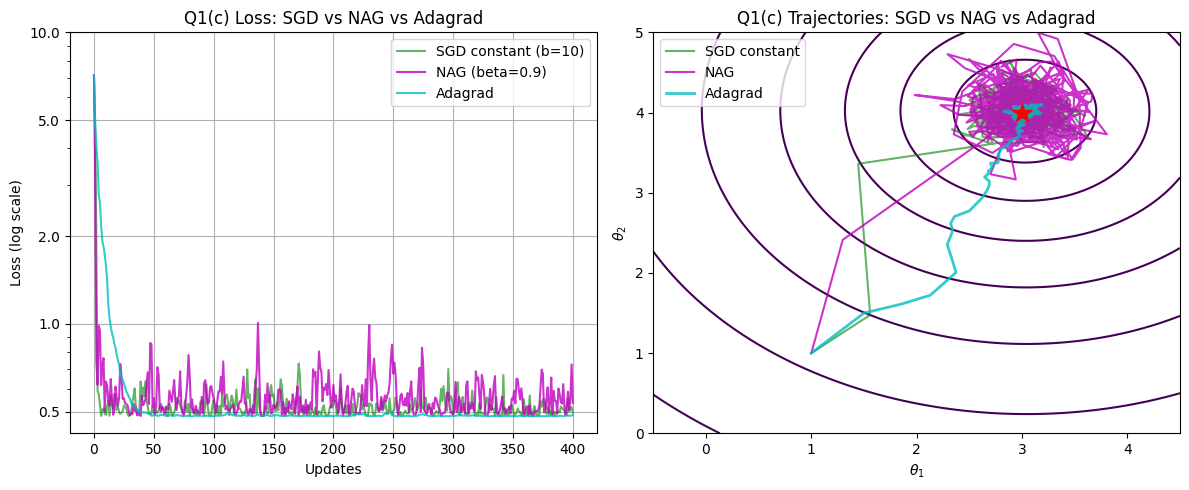

In [171]:
hist_sgd10, loss_sgd10 = mini_batch_sgd(X, y, theta_0, alpha=alpha_const, batch_size=10, updates=400, method='constant')
hist_nag, loss_nag = mini_batch_sgd(X, y, theta_0, alpha=alpha_const, batch_size=10, updates=400, method='NAG')
hist_ada, loss_ada = mini_batch_sgd(X, y, theta_0, alpha=alpha_const, batch_size=10, updates=400, method='Adagrad')

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss comparison plot
axes[0].plot(loss_sgd10, alpha=0.6, label='SGD constant (b=10)', color='g')
axes[0].plot(loss_nag, alpha=0.8, label='NAG (beta=0.9)', color='m')
axes[0].plot(loss_ada, alpha=0.8, label='Adagrad', color='c')
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter()) # Use standard numeric format
axes[0].set_yticks([0.5, 1, 2, 5, 10])
axes[0].set_title('Q1(c) Loss: SGD vs NAG vs Adagrad')
axes[0].set_xlabel('Updates')
axes[0].set_ylabel('Loss (log scale)')
axes[0].grid(True)
axes[0].legend()

# Trajectory comparison plot
axes[1].contour(T1, T2, Loss_grid, levels=np.logspace(-1, 3, 20), cmap='viridis')
axes[1].plot(hist_sgd10[:, 0], hist_sgd10[:, 1], 'g-', alpha=0.6, label='SGD constant')
axes[1].plot(hist_nag[:, 0], hist_nag[:, 1], 'm-', alpha=0.8, label='NAG')
axes[1].plot(hist_ada[:, 0], hist_ada[:, 1], 'c-', alpha=0.8, label='Adagrad', linewidth=2)
axes[1].plot(theta_star[0], theta_star[1], 'r*', markersize=15)
axes[1].set_title('Q1(c) Trajectories: SGD vs NAG vs Adagrad')
axes[1].set_xlabel(r'$\theta_1$')
axes[1].set_ylabel(r'$\theta_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

In [172]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
m = 1000
u = np.random.uniform(-2, 2, m)
x_star = np.array([1.0, 3.0])
epsilon = np.random.normal(0, 0.05, m)
y = x_star[1] * np.tanh(x_star[0] * u) + epsilon

x_0 = np.array([1.0, 1.0])
alpha_q2 = 0.75

# Calculate loss and gradient
def compute_loss_q2(x_val, u_data, y_data):
    y_hat = x_val[1] * np.tanh(x_val[0] * u_data)
    return np.mean(0.5 * (y_hat - y_data)**2)

def compute_gradient_q2(x_val, u_batch, y_batch):
    y_hat = x_val[1] * np.tanh(x_val[0] * u_batch)
    error = y_hat - y_batch
    
    sech2 = 1.0 - np.tanh(x_val[0] * u_batch)**2
    
    grad_x1 = np.mean(error * x_val[1] * sech2 * u_batch)
    grad_x2 = np.mean(error * np.tanh(x_val[0] * u_batch))
    
    return np.array([grad_x1, grad_x2])

# Grid data for contour plot
x1_vals = np.linspace(0.0, 2.0, 100)
x2_vals = np.linspace(0.0, 4.0, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
J_grid = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        J_grid[i, j] = compute_loss_q2(np.array([X1[i, j], X2[i, j]]), u, y)

# GD
def full_batch_gd_q2(u_data, y_data, x_init, alpha, iterations):
    x_val = x_init.copy()
    history = [x_val.copy()]
    losses = [compute_loss_q2(x_val, u_data, y_data)]
    
    for _ in range(iterations):
        grad = compute_gradient_q2(x_val, u_data, y_data)
        x_val = x_val - alpha * grad
        history.append(x_val.copy())
        losses.append(compute_loss_q2(x_val, u_data, y_data))
        
    return np.array(history), np.array(losses)

def mini_batch_sgd_q2(u_data, y_data, x_init, alpha, batch_size, updates, method='constant', beta=0.9, eps=1e-8):
    x_val = x_init.copy()
    history = [x_val.copy()]
    losses = [compute_loss_q2(x_val, u_data, y_data)]
    
    m_len = len(y_data)
    v = np.zeros_like(x_val) # for NAG
    G = np.zeros_like(x_val) # for Adagrad
    
    update_count = 0
    while update_count < updates:
        # Shuffle data every epoch
        indices = np.random.permutation(m_len)
        u_shuffled = u_data[indices]
        y_shuffled = y_data[indices]
        
        for i in range(0, m_len, batch_size):
            if update_count >= updates:
                break
                
            u_batch = u_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            if method == 'constant':
                grad = compute_gradient_q2(x_val, u_batch, y_batch)
                x_val = x_val - alpha * grad
                
            elif method == 'NAG':
                x_ahead = x_val - beta * v
                grad_ahead = compute_gradient_q2(x_ahead, u_batch, y_batch)
                v = beta * v + alpha * grad_ahead
                x_val = x_val - v
                
            elif method == 'Adagrad':
                grad = compute_gradient_q2(x_val, u_batch, y_batch)
                G += grad ** 2
                x_val = x_val - (alpha / np.sqrt(G + eps)) * grad
            
            history.append(x_val.copy())
            losses.append(compute_loss_q2(x_val, u_data, y_data))
            update_count += 1
            
    return np.array(history), np.array(losses)

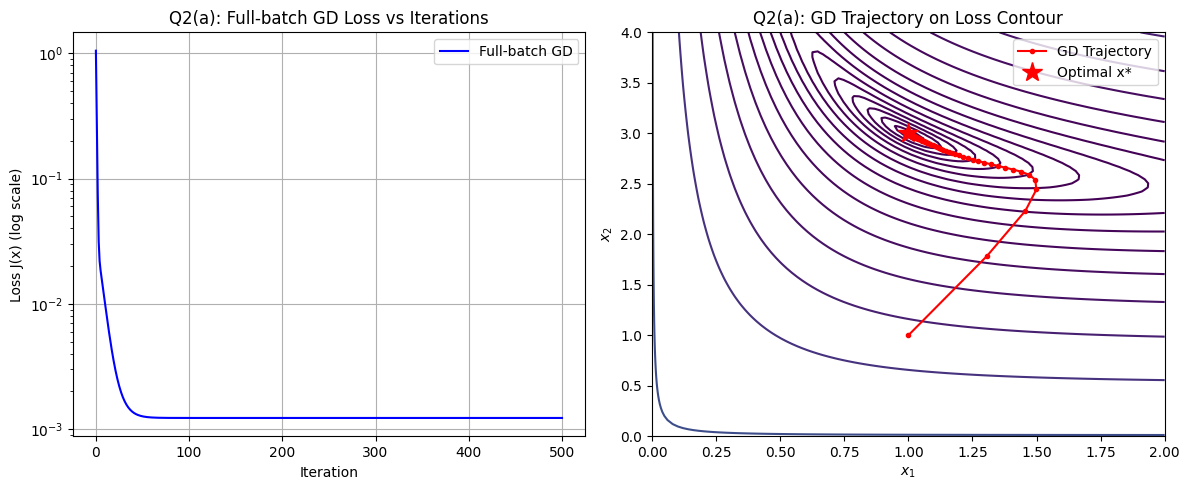

In [173]:

hist_gd_q2, loss_gd_q2 = full_batch_gd_q2(u, y, x_0, alpha=alpha_q2, iterations=500)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(loss_gd_q2, label='Full-batch GD', color='blue')
axes[0].set_yscale('log')
axes[0].set_title('Q2(a): Full-batch GD Loss vs Iterations')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss J(x) (log scale)')
axes[0].grid(True)
axes[0].legend()

levels = np.logspace(-3, 1, 20)
axes[1].contour(X1, X2, J_grid, levels=levels, cmap='viridis')
axes[1].plot(hist_gd_q2[:, 0], hist_gd_q2[:, 1], 'r.-', label='GD Trajectory')
axes[1].plot(x_star[0], x_star[1], 'r*', markersize=15, label='Optimal x*')
axes[1].set_title('Q2(a): GD Trajectory on Loss Contour')
axes[1].set_xlabel(r'$x_1$')
axes[1].set_ylabel(r'$x_2$')
axes[1].legend()

plt.tight_layout()
plt.show()


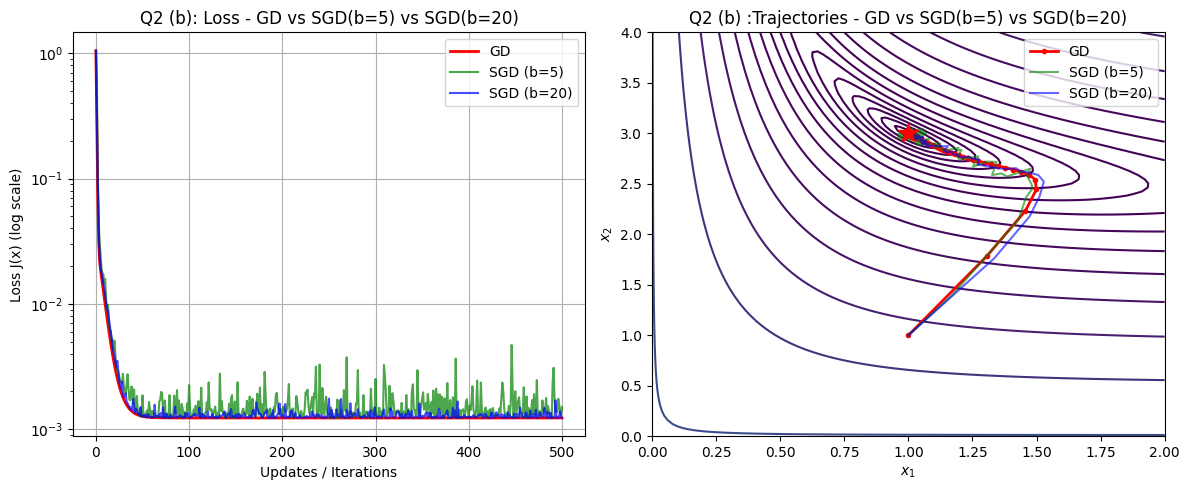

In [175]:
hist_sgd5_q2, loss_sgd5_q2 = mini_batch_sgd_q2(u, y, x_0, alpha=alpha_q2, batch_size=5, updates=500)
hist_sgd20_q2, loss_sgd20_q2 = mini_batch_sgd_q2(u, y, x_0, alpha=alpha_q2, batch_size=20, updates=500)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(loss_gd_q2, label='GD', color='r', linewidth=2)
axes[0].plot(loss_sgd5_q2, alpha=0.7, label='SGD (b=5)', color='g')
axes[0].plot(loss_sgd20_q2, alpha=0.7, label='SGD (b=20)', color='b')
axes[0].set_yscale('log')
axes[0].set_title('Q2 (b): Loss - GD vs SGD(b=5) vs SGD(b=20)')
axes[0].set_xlabel('Updates / Iterations')
axes[0].set_ylabel('Loss J(x) (log scale)')
axes[0].grid(True)
axes[0].legend()

axes[1].contour(X1, X2, J_grid, levels=levels, cmap='viridis')
axes[1].plot(hist_gd_q2[:, 0], hist_gd_q2[:, 1], 'r.-', label='GD', linewidth=2)
axes[1].plot(hist_sgd5_q2[:, 0], hist_sgd5_q2[:, 1], 'g-', alpha=0.6, label='SGD (b=5)')
axes[1].plot(hist_sgd20_q2[:, 0], hist_sgd20_q2[:, 1], 'b-', alpha=0.6, label='SGD (b=20)')
axes[1].plot(x_star[0], x_star[1], 'r*', markersize=15)
axes[1].set_title('Q2 (b) :Trajectories - GD vs SGD(b=5) vs SGD(b=20)')
axes[1].set_xlabel(r'$x_1$')
axes[1].set_ylabel(r'$x_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

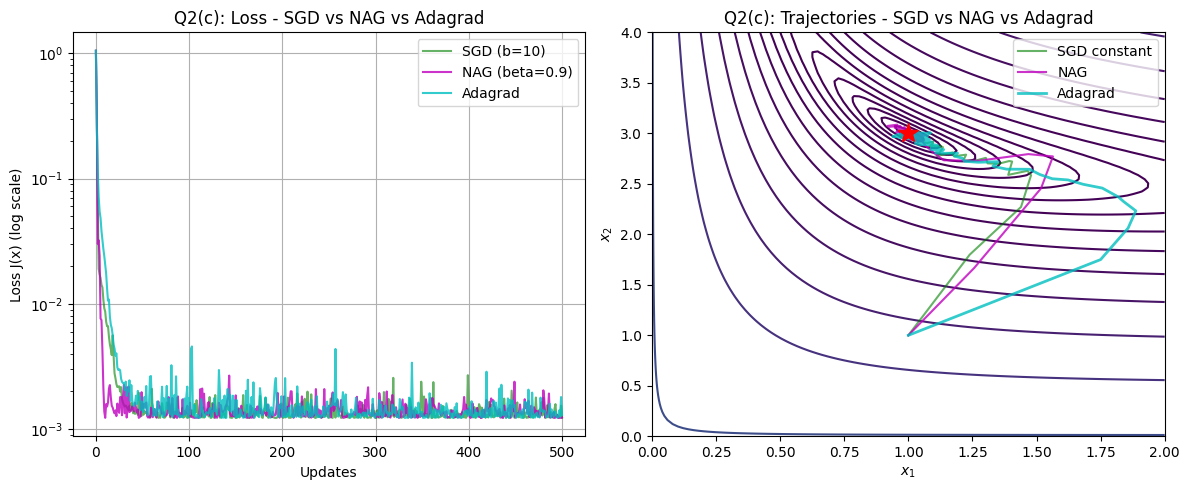

In [176]:
hist_sgd10_q2, loss_sgd10_q2 = mini_batch_sgd_q2(u, y, x_0, alpha=alpha_q2, batch_size=10, updates=500, method='constant')
hist_nag_q2, loss_nag_q2 = mini_batch_sgd_q2(u, y, x_0, alpha=alpha_q2, batch_size=10, updates=500, method='NAG')
hist_ada_q2, loss_ada_q2 = mini_batch_sgd_q2(u, y, x_0, alpha=alpha_q2, batch_size=10, updates=500, method='Adagrad')

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(loss_sgd10_q2, alpha=0.6, label='SGD (b=10)', color='g')
axes[0].plot(loss_nag_q2, alpha=0.8, label='NAG (beta=0.9)', color='m')
axes[0].plot(loss_ada_q2, alpha=0.8, label='Adagrad', color='c')
axes[0].set_yscale('log')
axes[0].set_title('Q2(c): Loss - SGD vs NAG vs Adagrad')
axes[0].set_xlabel('Updates')
axes[0].set_ylabel('Loss J(x) (log scale)')
axes[0].grid(True)
axes[0].legend()

axes[1].contour(X1, X2, J_grid, levels=levels, cmap='viridis')
axes[1].plot(hist_sgd10_q2[:, 0], hist_sgd10_q2[:, 1], 'g-', alpha=0.6, label='SGD constant')
axes[1].plot(hist_nag_q2[:, 0], hist_nag_q2[:, 1], 'm-', alpha=0.8, label='NAG')
axes[1].plot(hist_ada_q2[:, 0], hist_ada_q2[:, 1], 'c-', alpha=0.8, label='Adagrad', linewidth=2)
axes[1].plot(x_star[0], x_star[1], 'r*', markersize=15)
axes[1].set_title('Q2(c): Trajectories - SGD vs NAG vs Adagrad')
axes[1].set_xlabel(r'$x_1$')
axes[1].set_ylabel(r'$x_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(x):
    return (1.0 - x[0])**2 + 100.0 * (x[1] - x[0]**2)**2

def finite_diff_grad(f, x, h=1e-5):
    """Compute gradient using central difference method"""
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i] += h
        x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)
    return grad

def finite_diff_hess(f, x, h=1e-5):
    """Compute Hessian matrix using central difference method"""
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus = x.copy()
                x_minus = x.copy()
                x_plus[i] += h
                x_minus[i] -= h
                hess[i, i] = (f(x_plus) - 2*f(x) + f(x_minus)) / (h**2)
            else:
                x_pp = x.copy(); x_pp[i] += h; x_pp[j] += h
                x_pm = x.copy(); x_pm[i] += h; x_pm[j] -= h
                x_mp = x.copy(); x_mp[i] -= h; x_mp[j] += h
                x_mm = x.copy(); x_mm[i] -= h; x_mm[j] -= h
                hess[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * h**2)
    return hess

def gd_rosenbrock(x_init, alpha, iterations):
    """Gradient Descent"""
    x = x_init.copy()
    history, losses = [x.copy()], [rosenbrock(x)]
    for _ in range(iterations):
        grad = finite_diff_grad(rosenbrock, x)
        x = x - alpha * grad
        history.append(x.copy())
        losses.append(rosenbrock(x))
    return np.array(history), np.array(losses)

def newton_rosenbrock(x_init, alpha, iterations):
    """Standard Newton's Method"""
    x = x_init.copy()
    history, losses = [x.copy()], [rosenbrock(x)]
    for _ in range(iterations):
        g = finite_diff_grad(rosenbrock, x)
        H = finite_diff_hess(rosenbrock, x)
        p = np.linalg.inv(H).dot(g)
        x = x - alpha * p
        history.append(x.copy())
        losses.append(rosenbrock(x))
    return np.array(history), np.array(losses)

def damped_newton_rosenbrock(x_init, alpha_0=1.0, rho=0.5, max_k=10, iterations=200, lambda_reg=1e-6):
    """Damped Newton's Method"""
    x = x_init.copy()
    history, losses = [x.copy()], [rosenbrock(x)]
    
    for _ in range(iterations):
        f_t = rosenbrock(x)
        g_t = finite_diff_grad(rosenbrock, x)
        H_t = finite_diff_hess(rosenbrock, x)
        
        # Solve for Newton direction p_t
        p_t = np.linalg.inv(H_t).dot(g_t)        
        alpha = alpha_0
        step_accepted = False
        
        # Backtracking line search
        for k in range(max_k):
            x_new = x - alpha * p_t
            if rosenbrock(x_new) < f_t:
                step_accepted = True
                break
            else:
                alpha *= rho
                
        # Alternative fallback solution
        if not step_accepted:
            x_new = x - 1e-4 * g_t
            
        x = x_new
        history.append(x.copy())
        losses.append(rosenbrock(x))
        
    return np.array(history), np.array(losses)

# Grid data for contour plot
x1_vals = np.linspace(-2.0, 2.0, 200)
x2_vals = np.linspace(-1.0, 3.0, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
F_grid = (1.0 - X1)**2 + 100.0 * (X2 - X1**2)**2

x_0 = np.array([-1.0, 1.0])

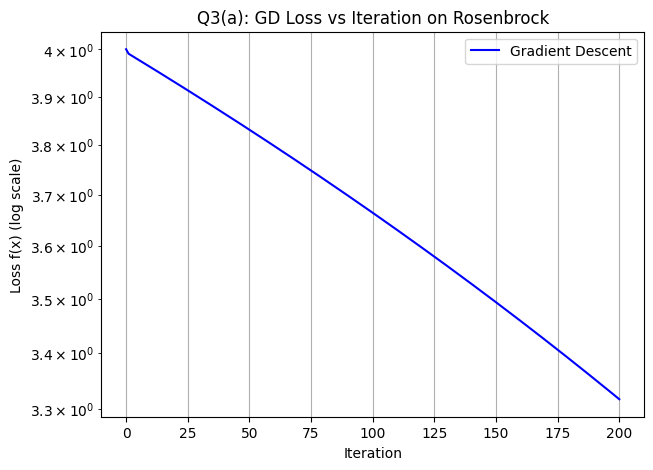

In [178]:
hist_gd_q3, loss_gd_q3 = gd_rosenbrock(x_0, alpha=1e-3, iterations=200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(loss_gd_q3, label='Gradient Descent', color='blue')
ax.set_yscale('log')
ax.set_title('Q3(a): GD Loss vs Iteration on Rosenbrock')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss f(x) (log scale)')
ax.grid(True)
ax.legend()
plt.show()

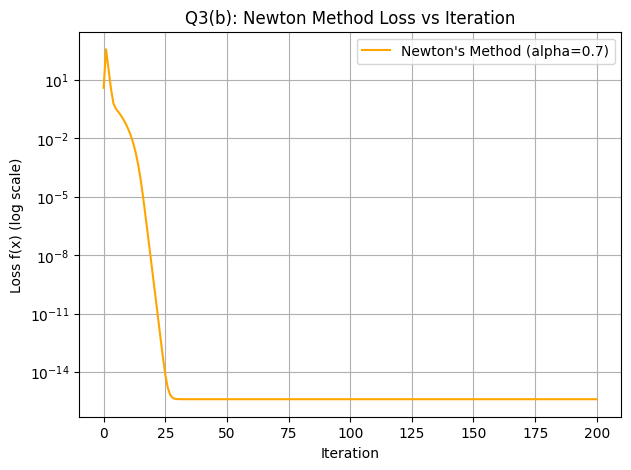

In [179]:
hist_nt_q3, loss_nt_q3 = newton_rosenbrock(x_0, alpha=0.7, iterations=200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(loss_nt_q3, label="Newton's Method (alpha=0.7)", color='orange')
ax.set_yscale('log')
ax.set_title('Q3(b): Newton Method Loss vs Iteration')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss f(x) (log scale)')
ax.grid(True)
ax.legend()
plt.show()

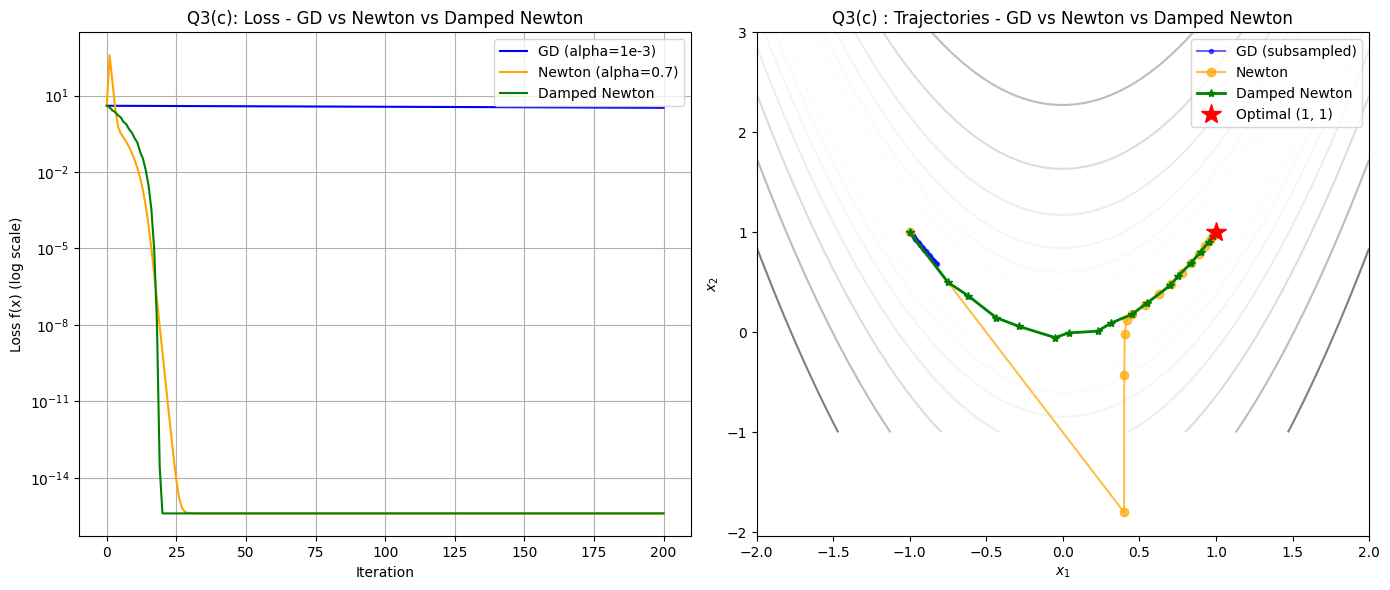

In [180]:
hist_dnt_q3, loss_dnt_q3 = damped_newton_rosenbrock(x_0, alpha_0=1.0, rho=0.5, iterations=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss comparison plot
axes[0].plot(loss_gd_q3, label='GD (alpha=1e-3)', color='blue')
axes[0].plot(loss_nt_q3, label='Newton (alpha=0.7)', color='orange')
axes[0].plot(loss_dnt_q3, label='Damped Newton', color='green')
axes[0].set_yscale('log')
axes[0].set_title('Q3(c): Loss - GD vs Newton vs Damped Newton')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss f(x) (log scale)')
axes[0].grid(True)
axes[0].legend()

# Contour trajectory comparison plot
levels = np.logspace(-1, 3, 15)
axes[1].contour(X1, X2, F_grid, levels=levels, cmap='gray_r', alpha=0.5)

# GD trajectory
axes[1].plot(hist_gd_q3[::10, 0], hist_gd_q3[::10, 1], 'b.-', alpha=0.6, label='GD (subsampled)')

# Newton trajectory
axes[1].plot(hist_nt_q3[:, 0], hist_nt_q3[:, 1], 'o-', color='orange', alpha=0.7, label='Newton')

# Damped Newton trajectory
axes[1].plot(hist_dnt_q3[:, 0], hist_dnt_q3[:, 1], 'g*-', linewidth=2, label='Damped Newton')

# Mark the optimal point
axes[1].plot(1.0, 1.0, 'r*', markersize=15, label='Optimal (1, 1)')

axes[1].set_title('Q3(c) : Trajectories - GD vs Newton vs Damped Newton')
axes[1].set_xlabel(r'$x_1$')
axes[1].set_ylabel(r'$x_2$')
axes[1].legend()

plt.tight_layout()
plt.show()